In [1]:
import osmnx as ox

place_name = "Jakarta, Indonesia"

print(f"Downloading street network for {place_name}...")

G = ox.graph_from_place(place_name, network_type='drive')

print(f"Successfully downloaded graph!")
print(G)

Successfully downloaded graph!
MultiDiGraph with 92967 nodes and 213016 edges


Plotting graph...


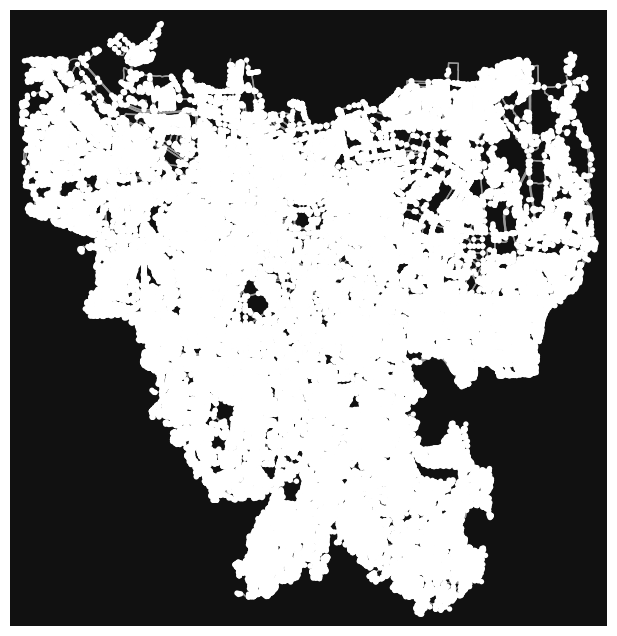

In [2]:
import matplotlib.pyplot as plt
print("Plotting graph...")
fig, ax = ox.plot_graph(G, show=False, close=False)
plt.show()

In [3]:
# Get the first node's ID and its attributes
first_node_data = list(G.nodes(data=True))[0]
print(first_node_data)

(29938969, {'y': -6.180894, 'x': 106.8230517, 'street_count': 3})


In [4]:
# Get the first edge's data (start_node, end_node, key, attributes)
first_edge_data = list(G.edges(data=True, keys=True))[4676]
print(first_edge_data)

(315206972, 6829410440, 0, {'osmid': 696130286, 'highway': 'secondary', 'lanes': '4', 'name': 'Jalan Pangeran Diponegoro', 'oneway': True, 'width': '5', 'reversed': False, 'length': 18.74522501144508})


In [5]:
import osmnx as ox
import pandas as pd
import numpy as np 

gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

gdf_edges = gdf_edges.reset_index()

print("--- Edge DataFrame Info (shows non-null counts) ---")
gdf_edges.info()

# Get an exact count of missing values for each column
print("\n--- Count of Missing Values per Column ---")
print(gdf_edges.isnull().sum())

--- Edge DataFrame Info (shows non-null counts) ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 213016 entries, 0 to 213015
Data columns (total 19 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   u          213016 non-null  int64   
 1   v          213016 non-null  int64   
 2   key        213016 non-null  int64   
 3   osmid      213016 non-null  object  
 4   highway    213016 non-null  object  
 5   junction   614 non-null     object  
 6   lanes      161472 non-null  object  
 7   oneway     213016 non-null  bool    
 8   reversed   213016 non-null  object  
 9   length     213016 non-null  float64 
 10  geometry   213016 non-null  geometry
 11  name       151931 non-null  object  
 12  width      155624 non-null  object  
 13  est_width  5458 non-null    object  
 14  bridge     4170 non-null    object  
 15  access     23543 non-null   object  
 16  ref        1593 non-null    object  
 17  maxspeed   3519 non-null  

In [6]:
print(gdf_edges["maxspeed"].value_counts())

maxspeed
20           963
10           690
40           508
30           427
5            259
25           208
80           174
60           165
100           49
50            27
20,30,40      15
15            14
45             6
[100, 80]      6
[10, 20]       4
[100, 40]      1
[60, 100]      1
[40, 80]       1
[60, 20]       1
Name: count, dtype: int64


In [7]:
import psycopg2
from sqlalchemy import create_engine, text
import sys

# --- Configuration ---
DB_HOST = 'cs-u-spatial-406.cs.umn.edu'
DB_NAME = 'gis'
DB_USER = 'gis'
DB_PASS = 'gis'
DB_PORT = 5432

# Setup the connection 
connection_str = f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(connection_str)

with engine.connect() as connection:
    
    result = connection.execute(text("SELECT * FROM road_attributes LIMIT 0"))
    columns = result.keys()
    
    print("--- Columns in 'road_attributes' table ---")
    for col in columns:
        print(col)

--- Columns in 'road_attributes' table ---
osm_id
oneway
road_type
width
nlanes
max_speed
min_speed
avg_speed
oneway_source
road_type_source
width_source
nlanes_source
max_speed_source
min_speed_source
avg_speed_source
oneway_conf
road_type_conf
width_conf
nlanes_conf
max_speed_conf
min_speed_conf
avg_speed_conf
geometry
id


In [8]:
import psycopg2
from sqlalchemy import create_engine, text
import sys

# --- Configuration ---
DB_HOST = 'cs-u-spatial-406.cs.umn.edu'
DB_NAME = 'gis'
DB_USER = 'gis'
DB_PASS = 'gis'
DB_PORT = 5432


connection_str = f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(connection_str)

def simplify_id(val):
    if isinstance(val, list):
        return val[0] # Take the first ID if it's a list
    return val

# Apply it to the osmid column
gdf_edges['osmid'] = gdf_edges['osmid'].apply(simplify_id)

# Get the list of OSM IDs from local DataFrame
# Ensure they are integers
ids_to_fetch = gdf_edges['osmid'].astype(int).unique().tolist()

print(f"Looking up {len(ids_to_fetch)} unique OSM IDs in the remote database...")

# Define a function to fetch data in chunks to avoid crashing the query
def fetch_attributes_in_chunks(id_list, chunk_size=5000):
    all_results = []
    
    # Loop through the IDs in steps of 'chunk_size'
    for i in range(0, len(id_list), chunk_size):
        chunk = id_list[i : i + chunk_size]
        
        # Format the IDs for SQL (e.g., "123, 456, 789")
        ids_tuple = str(tuple(chunk)).replace(',)', ')') # Handle single-element tuple quirk
        
        # Query: Select only the columns we need
        query = f"""
            SELECT osm_id, nlanes, width, max_speed 
            FROM road_attributes 
            WHERE osm_id IN {ids_tuple}
        """
        
        # Run query and append to list
        chunk_df = pd.read_sql(query, engine)
        all_results.append(chunk_df)
        
        print(f"  Fetched batch {i} to {i+chunk_size}...")

    # Combine all chunks into one DataFrame
    if all_results:
        return pd.concat(all_results, ignore_index=True)
    return pd.DataFrame()

# Execute the fetch
db_data = fetch_attributes_in_chunks(ids_to_fetch)

# Clean up the external data before merging
# Rename columns to match your 'osmnx' DataFrame for easier merging later
db_data = db_data.rename(columns={
    'osm_id': 'osmid',
    'nlanes': 'lanes_db',
    'width': 'width_db',
    'max_speed': 'maxspeed_db'
})

# Ensure osmid is the same type (string/object) as your local df for merging
db_data['osmid'] = db_data['osmid'].astype(str)

print(f"\nSuccessfully retrieved {len(db_data)} rows from the database.")
print(db_data.head())

Looking up 69054 unique OSM IDs in the remote database...
  Fetched batch 0 to 5000...
  Fetched batch 5000 to 10000...
  Fetched batch 10000 to 15000...
  Fetched batch 15000 to 20000...
  Fetched batch 20000 to 25000...
  Fetched batch 25000 to 30000...
  Fetched batch 30000 to 35000...
  Fetched batch 35000 to 40000...
  Fetched batch 40000 to 45000...
  Fetched batch 45000 to 50000...
  Fetched batch 50000 to 55000...
  Fetched batch 55000 to 60000...
  Fetched batch 60000 to 65000...
  Fetched batch 65000 to 70000...

Successfully retrieved 68578 rows from the database.
      osmid  lanes_db  width_db  maxspeed_db
0   4705043       1.0       4.0          NaN
1   4705046       2.0       6.0          NaN
2  10521974       1.0       NaN          NaN
3  10700207       2.0       NaN          NaN
4  10700233       2.0       NaN          NaN


In [9]:
print(db_data.info())

print(gdf_edges.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68578 entries, 0 to 68577
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   osmid        68578 non-null  object 
 1   lanes_db     47289 non-null  float64
 2   width_db     43104 non-null  float64
 3   maxspeed_db  1091 non-null   float64
dtypes: float64(3), object(1)
memory usage: 2.1+ MB
None
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 213016 entries, 0 to 213015
Data columns (total 19 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   u          213016 non-null  int64   
 1   v          213016 non-null  int64   
 2   key        213016 non-null  int64   
 3   osmid      213016 non-null  int64   
 4   highway    213016 non-null  object  
 5   junction   614 non-null     object  
 6   lanes      161472 non-null  object  
 7   oneway     213016 non-null  bool    
 8   reversed   213016 non-null  object  
 9

In [10]:
# gdf_edges['width'] = gdf_edges['width'].fillna(gdf_edges['est_width']) Will do it lastly
columns_to_drop = ["junction", "bridge", "access", "ref","tunnel", "reversed", "name"]
gdf_edges = gdf_edges.drop(columns = columns_to_drop)
print(gdf_edges.isnull().sum())

u                 0
v                 0
key               0
osmid             0
highway           0
lanes         51544
oneway            0
length            0
geometry          0
width         57392
est_width    207558
maxspeed     209497
dtype: int64


In [11]:
print(gdf_edges["maxspeed"].value_counts())

maxspeed
20           963
10           690
40           508
30           427
5            259
25           208
80           174
60           165
100           49
50            27
20,30,40      15
15            14
45             6
[100, 80]      6
[10, 20]       4
[100, 40]      1
[60, 100]      1
[40, 80]       1
[60, 20]       1
Name: count, dtype: int64


In [12]:
print(gdf_edges["lanes"].value_counts())

lanes
1                      104514
2                       51791
3                        2280
[1, 2]                   1315
4                         854
[3, 2]                    287
[4, 3]                    178
[4, 2]                     51
5                          46
[3, 1, 2]                  30
[3, 1]                     28
[4, 3, 2]                  22
[4, 5]                     16
[4, 1]                     10
[3, 5]                      7
6                           6
[4, 3, 5]                   4
[4, 1, 2]                   4
[4, 6, 5]                   4
[6, 5]                      3
[4, 3, 1, 2]                3
[1, 5]                      2
[5, 2]                      1
[4, 6]                      1
[1, 2, 5]                   1
[6, 3, 8, 5]                1
[4, 3, 6]                   1
[2, 5]                      1
[3, 5, 2]                   1
[6, 3, 1, 2]                1
[6, 4, 5]                   1
[4, 5, 9, 3, 2]             1
[6, 2]                      1
[11,

In [13]:
for val in gdf_edges["width"].value_counts().index:
    print(val)

3
4
5
2
6
2.5
1
8
7
1.5
3.5
10
['4', '3']
12
1.8
9
['3', '2']
2.2
0.5
2.75
1.2
4.5
1.3
2.3
['4', '5']
['1', '2']
15
['3', '2.5']
['1.5', '2']
5.5
['4', '2']
['3', '1']
2.1
['3', '1.5']
['3', '5']
['6', '5']
['1', '1.5']
1.7
5;6
1.4
['2.5', '2']
['2', '2.5']
2.8
0.8
['6', '8']
1.6
['4', '1']
4;6;5
['3.5', '2']
['6', '3']
7.5
['6', '4']
['1.5', '2.5']
['1', '2.5']
1.25
['4', '6']
['4', '3.5']
0.75
['4', '2.5']
1.9
['8', '5']
3.2
20
['2', '5']
2.7
['7', '5']
['6', '7']
['5', '2']
['4', '1.5']
5.2
['3.5', '3']
['3', '3.5']
['1.8', '2']
['3.5', '5']
['3.5', '2.5']
['1', '5']
0.7
4.16
5.8
['10', '8']
10.2
2.4
['1.8', '2.5']
['0.5', '2']
3;6
3.3
['3.5', '1.5']
['4', '8']
4.09
['2.5', '5']
['5', '2.5']
['4', '7']
['7', '8']
['1.5', '5']
['4', '3', '2']
0.6
['6', '2']
3.6
16.7
5.05
['3', '7']
['6', '12']
4.6
3.4
8.56
['4.5', '5']
11.6
42
['3.5', '1']
['6', '2.5']
['10', '6']
['10', '7']
['1.2', '1.3']
3.49
11
['3', '1.5', '2']
5.07
['6', '10']
['3', '1.8']
['4', '1', '2']
['1.2', '2.3']
['1.2',

In [14]:
print(gdf_edges["highway"].value_counts())

highway
residential                                   118452
living_street                                  53492
tertiary                                       21280
secondary                                       6564
primary                                         4625
trunk                                           1799
unclassified                                    1513
[residential, living_street]                    1029
[living_street, residential]                     991
primary_link                                     823
trunk_link                                       588
motorway_link                                    503
secondary_link                                   482
tertiary_link                                    363
motorway                                         292
busway                                           129
[residential, unclassified]                       18
[unclassified, residential]                       15
[unclassified, living_street]         

In [15]:
import pandas as pd
import numpy as np
import ast

def _parse_item_as_float(item):
    """Converts a single item (which could be '3;4') to a float."""
    s_item = str(item).lower().replace('m', '').strip()
    if ';' in s_item:
        # Value is '3;4'. Split, parse each, and sum.
        return float(s_item.split(';')[0])
        
    else:
        # Value is '3' or '4.5'. Just parse.
        return float(s_item)

def clean_lanes(value):
    s_val = str(value) 
    if s_val == 'nan' or s_val == 'None':
        return np.nan
    
    if s_val.startswith('['):
        lanes_list = ast.literal_eval(s_val)
        # Apply the helper to each item, sum them, then convert to int
        return int(_parse_item_as_float(lanes_list[0]))
    
    # It's a single value, convert it
    return int(_parse_item_as_float(s_val))

def clean_width(value):
    s_val = str(value) 
    if s_val == 'nan' or s_val == 'None':
        return np.nan
    
    if s_val.startswith('['):
        width_list = ast.literal_eval(s_val)

        # Calculate the list of floats first
        vals = [_parse_item_as_float(item) for item in width_list]
        # Return the sum divided by the length (Average)
        return sum(vals) / len(vals)

    return _parse_item_as_float(s_val)

def clean_maxspeed(value):
    s_val = str(value)
    if s_val == 'nan' or s_val == 'None':
        return np.nan
    
    if s_val.startswith('['):
        maxspeed_list = ast.literal_eval(s_val)
        # Take the first item, ensure it's a float
        return float(_parse_item_as_float(maxspeed_list[0]))
    elif len(s_val.split(",")) > 1:
        # Multiple values separated by commas, take the first
        first_item = s_val.split(",")[0].strip()
        return float(_parse_item_as_float(first_item))
    # Single value
    return float(_parse_item_as_float(s_val))

def clean_highway(value):
    s_val = str(value)
    if s_val == 'nan' or s_val == 'None':
        return 'unknown'
    
    if s_val.startswith('['):
        return s_val.strip('[]').split(',')[0].strip().strip("'\"")
    
    return value

print("Cleaning 'lanes'...")
gdf_edges['lanes'] = gdf_edges['lanes'].apply(clean_lanes)

print("Cleaning 'width'...")
gdf_edges['width'] = gdf_edges['width'].apply(clean_width)
print("Done cleaning 'width'.")

print("Cleaning 'oneway'...")
gdf_edges['oneway'] = gdf_edges['oneway'].astype(int)

print("Cleaning 'maxspeed'...")
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].apply(clean_maxspeed)

print("Cleaning and one-hot encoding 'highway'...")
gdf_edges['highway'] = gdf_edges['highway'].apply(clean_highway)

print("\n--- Final DataFrame Columns ---")
print(gdf_edges.columns)

Cleaning 'lanes'...
Cleaning 'width'...
Done cleaning 'width'.
Cleaning 'oneway'...
Cleaning 'maxspeed'...
Cleaning and one-hot encoding 'highway'...

--- Final DataFrame Columns ---
Index(['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'oneway', 'length',
       'geometry', 'width', 'est_width', 'maxspeed'],
      dtype='object')


In [16]:
print(gdf_edges.isnull().sum())

u                 0
v                 0
key               0
osmid             0
highway           0
lanes         51544
oneway            0
length            0
geometry          0
width         57392
est_width    207558
maxspeed     209497
dtype: int64


In [17]:
print(db_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68578 entries, 0 to 68577
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   osmid        68578 non-null  object 
 1   lanes_db     47289 non-null  float64
 2   width_db     43104 non-null  float64
 3   maxspeed_db  1091 non-null   float64
dtypes: float64(3), object(1)
memory usage: 2.1+ MB
None


In [18]:
# You have lanes, width, maxspeed in the database, use them

# 1. Prepare the Database Data
# We rename the DB columns so they don't clash with your existing ones yet.
# Mapping: DB Column -> Temporary Name
db_formatted = db_data.rename(columns={
    'osm_id': 'osmid',
    'nlanes': 'lanes_db',
    'max_speed': 'maxspeed_db',
    'width': 'width_db'
})

# 2. Ensure the 'key' column is the same type in both DataFrames
# (String is safest for IDs to avoid floating point errors)
gdf_edges['osmid'] = gdf_edges['osmid'].astype(str)
db_formatted['osmid'] = db_formatted['osmid'].astype(str)

print("Merging dataframes...")

# 3. Perform the Left Merge
# We keep ALL rows from gdf_edges (left) and attach DB info where available.
merged_df = gdf_edges.merge(db_formatted, on='osmid', how='left')

# 4. Impute Missing Values
# Logic: "Use the value we already have. If it's missing (NaN), use the DB value."
print("Filling missing values...")

merged_df['lanes'] = merged_df['lanes'].fillna(merged_df['lanes_db'])
merged_df['maxspeed'] = merged_df['maxspeed'].fillna(merged_df['maxspeed_db'])
merged_df['width'] = merged_df['width'].fillna(merged_df['width_db'])

# 5. Cleanup
# Drop the temporary columns we just used
final_gdf = merged_df.drop(columns=['lanes_db', 'maxspeed_db', 'width_db'])

# 6. Check the Results
print("\n--- Missing Values BEFORE Database Fill ---")
print(gdf_edges.isnull().sum())

print("\n--- Missing Values AFTER Database Fill ---")
print(final_gdf.isnull().sum())

Merging dataframes...
Filling missing values...

--- Missing Values BEFORE Database Fill ---
u                 0
v                 0
key               0
osmid             0
highway           0
lanes         51544
oneway            0
length            0
geometry          0
width         57392
est_width    207558
maxspeed     209497
dtype: int64

--- Missing Values AFTER Database Fill ---
u                 0
v                 0
key               0
osmid             0
highway           0
lanes         51534
oneway            0
length            0
geometry          0
width         57390
est_width    207558
maxspeed     209491
dtype: int64


In [19]:
print(final_gdf.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 213016 entries, 0 to 213015
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   u          213016 non-null  int64   
 1   v          213016 non-null  int64   
 2   key        213016 non-null  int64   
 3   osmid      213016 non-null  object  
 4   highway    213016 non-null  object  
 5   lanes      161482 non-null  float64 
 6   oneway     213016 non-null  int64   
 7   length     213016 non-null  float64 
 8   geometry   213016 non-null  geometry
 9   width      155626 non-null  float64 
 10  est_width  5458 non-null    object  
 11  maxspeed   3525 non-null    float64 
dtypes: float64(4), geometry(1), int64(4), object(3)
memory usage: 19.5+ MB
None


In [20]:
# final_gdf['width'] = final_gdf['width'].fillna(final_gdf['est_width'])
final_gdf = final_gdf.drop(columns = ["est_width", "maxspeed"])

In [21]:
print(final_gdf.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 213016 entries, 0 to 213015
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   u         213016 non-null  int64   
 1   v         213016 non-null  int64   
 2   key       213016 non-null  int64   
 3   osmid     213016 non-null  object  
 4   highway   213016 non-null  object  
 5   lanes     161482 non-null  float64 
 6   oneway    213016 non-null  int64   
 7   length    213016 non-null  float64 
 8   geometry  213016 non-null  geometry
 9   width     155626 non-null  float64 
dtypes: float64(3), geometry(1), int64(4), object(2)
memory usage: 16.3+ MB
None


In [29]:
# =========================
# 0) Imports
# =========================
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 1) Helpers: parsing & encoding
# =========================

def lanes_to_class(x):
    """
    x: numeric lanes value or NaN
    returns:
      -1 if NaN
       0 for 1 lane
       1 for 2 lanes
       2 for 3+ lanes
    """
    if pd.isna(x):
        return -1
    # If lanes are floats like 1.0, 2.0, 3.0
    v = float(x)

    if v <= 1.0:
        return 0
    elif v <= 2.0:
        return 1
    else:
        return 2

class ZScaler:
    """Z-score scaler that ignores NaN."""
    def __init__(self):
        self.mu = None
        self.sd = None

    def fit(self, x: np.ndarray):
        self.mu = np.nanmean(x)
        self.sd = np.nanstd(x) + 1e-8

    def transform(self, x: np.ndarray):
        return (x - self.mu) / self.sd

# =========================
# 2) Build line graph adjacency from (u,v)
# =========================
def build_line_graph_edge_index(df, u_col="u", v_col="v", eid_col="eid"):
    """
    Nodes in line graph = edges in original graph (df rows).
    Two line-graph nodes connect if original edges share an endpoint (u or v).
    """
    incident = {}
    u_vals = df[u_col].values
    v_vals = df[v_col].values
    eids  = df[eid_col].values

    for u, v, eid in zip(u_vals, v_vals, eids):
        incident.setdefault(u, []).append(eid)
        incident.setdefault(v, []).append(eid)

    pairs = []
    for node, lst in incident.items():
        m = len(lst)
        if m < 2:
            continue
        # clique among incident edges
        for i in range(m):
            for j in range(i + 1, m):
                a, b = lst[i], lst[j]
                pairs.append((a, b))
                pairs.append((b, a))

    edge_index = torch.tensor(pairs, dtype=torch.long).t().contiguous()
    return edge_index

# =========================
# 3) Prepare dataframe: ids, parsing, vocab
# =========================
df = final_gdf.copy()

# Stable node id for line graph nodes
df = df.reset_index(drop=True)
df["eid"] = np.arange(len(df), dtype=np.int64)

# Parse width to float
df["width_m"] = df["width"]

# Lanes class 0/1/2, missing -1
df["lanes_cls"] = df["lanes"].apply(lanes_to_class).astype(np.int64)

# Oneway to 0/1 int
# your final_gdf shows oneway is int64 already; this keeps it safe:
df["oneway01"] = df["oneway"].astype(int).astype(np.int64)

# Highway categorical vocab (add MASK and UNK)
highway_vals = df["highway"].astype(str).fillna("UNK").values
unique_highways = sorted(pd.unique(highway_vals).tolist())

MASK_TOKEN = "__MASK__"
UNK_TOKEN  = "__UNK__"

# Ensure UNK exists (in case there were NaNs or unseen later)
if UNK_TOKEN not in unique_highways:
    unique_highways.append(UNK_TOKEN)
# Add MASK as special id
if MASK_TOKEN in unique_highways:
    unique_highways.remove(MASK_TOKEN)
unique_highways.append(MASK_TOKEN)

hwy2id = {h:i for i,h in enumerate(unique_highways)}
id2hwy = {i:h for h,i in hwy2id.items()}

df["highway_id"] = df["highway"].astype(str).map(lambda x: hwy2id.get(x, hwy2id[UNK_TOKEN])).astype(np.int64)

# Special IDs
HIGHWAY_MASK_ID = hwy2id[MASK_TOKEN]

LANES_MASK_ID = 3   # lanes classes are 0,1,2; reserve 3 for MASK
LANES_MISS_ID = 4   # reserve 4 for MISSING (optional but helpful)

ONEWAY_MASK_VAL = -1  # sentinel in the categorical oneway ids (we'll use embedding-like ids)

# =========================
# 4) Train/Val/Test split (node-level)
# =========================
N = len(df)
perm = np.random.permutation(N)
n_train = int(0.80 * N)
n_val   = int(0.10 * N)

train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train+n_val]
test_idx  = perm[n_train+n_val:]

train_mask = np.zeros(N, dtype=bool); train_mask[train_idx] = True
val_mask   = np.zeros(N, dtype=bool); val_mask[val_idx] = True
test_mask  = np.zeros(N, dtype=bool); test_mask[test_idx] = True

# =========================
# 5) Normalize continuous features (train-only, ignore NaNs)
# =========================
# Length: log1p then z-score (length appears complete, but we do it generally)
length_raw = df["length"].to_numpy(dtype=np.float32)
length_log = np.log1p(length_raw)

width_raw = df["width_m"].to_numpy(dtype=np.float32)  # contains NaN

len_scaler = ZScaler()
wid_scaler = ZScaler()

len_scaler.fit(length_log[train_idx])
wid_scaler.fit(width_raw[train_idx])  # ignores NaN

length_z = len_scaler.transform(length_log).astype(np.float32)
width_z  = wid_scaler.transform(width_raw).astype(np.float32)  # NaN stays NaN

# For INPUTS: replace NaN with 0.0 (mask token for continuous)
width_z_in  = np.nan_to_num(width_z, nan=0.0).astype(np.float32)

# =========================
# 6) Build PyG Data: base inputs + targets
# =========================
# We'll build inputs using:
# - continuous: length_z, width_z_in
# - categorical ids: highway_id, lanes_input_id, oneway_input_id
#
# For lanes input id: use lanes_cls when present else LANES_MISS_ID
lanes_in_id = df["lanes_cls"].to_numpy(dtype=np.int64)
lanes_in_id = np.where(lanes_in_id == -1, LANES_MISS_ID, lanes_in_id)

# For oneway input id: map 0/1 to 0/1, no missing in your data, but reserve MASK later
oneway_in_id = df["oneway01"].to_numpy(dtype=np.int64)  # 0/1

# Targets
y_highway = df["highway_id"].to_numpy(dtype=np.int64)
y_lanes   = df["lanes_cls"].to_numpy(dtype=np.int64)    # -1 for missing
y_oneway  = df["oneway01"].to_numpy(dtype=np.float32)   # BCE expects float 0/1
y_width   = df["width_m"].to_numpy(dtype=np.float32)    # NaN allowed
y_length  = length_log.astype(np.float32)               # use log1p length as regression target

# Edge index for line graph
edge_index = build_line_graph_edge_index(df, u_col="u", v_col="v", eid_col="eid")
print("Line graph edge_index:", edge_index.shape)

data = Data(
    # continuous base channels (2)
    x_cont=torch.tensor(np.column_stack([length_z, width_z_in]), dtype=torch.float32),
    edge_index=edge_index
)

# Store categorical input ids
data.highway_in = torch.tensor(df["highway_id"].to_numpy(dtype=np.int64), dtype=torch.long)
data.lanes_in   = torch.tensor(lanes_in_id, dtype=torch.long)
data.oneway_in  = torch.tensor(oneway_in_id, dtype=torch.long)

# Store targets
data.y_highway = torch.tensor(y_highway, dtype=torch.long)
data.y_lanes   = torch.tensor(y_lanes, dtype=torch.long)
data.y_oneway  = torch.tensor(y_oneway, dtype=torch.float32)
data.y_width   = torch.tensor(y_width, dtype=torch.float32)
data.y_length  = torch.tensor(y_length, dtype=torch.float32)

# Splits
data.train_idx = torch.tensor(train_idx, dtype=torch.long)
data.val_idx   = torch.tensor(val_idx, dtype=torch.long)
data.test_idx  = torch.tensor(test_idx, dtype=torch.long)

# Move static tensors to device later; we will clone inputs per epoch for masking
data = data.to(device)

# =========================
# 7) Model: embeddings + 2-layer GATv2Conv + multi-head decoders
# =========================
class MultiAttrGAT(nn.Module):
    def __init__(self, num_highway, hwy_emb_dim=16,
                 lanes_emb_dim=8, oneway_emb_dim=4,
                 cont_dim=2, hidden=32, heads=2, dropout=0.1):
        super().__init__()

        # Embeddings for categorical inputs
        self.hwy_emb = nn.Embedding(num_highway, hwy_emb_dim)
        # lanes ids: 0,1,2 + MASK(3) + MISSING(4) => size 5
        self.lanes_emb = nn.Embedding(5, lanes_emb_dim)
        # oneway ids: 0,1 + MASK(2) => size 3
        self.oneway_emb = nn.Embedding(3, oneway_emb_dim)

        in_dim = cont_dim + hwy_emb_dim + lanes_emb_dim + oneway_emb_dim

        self.gat1 = GATv2Conv(in_dim, hidden, heads=heads, concat=True, dropout=dropout)
        self.gat2 = GATv2Conv(hidden * heads, hidden, heads=heads, concat=False, dropout=dropout)

        # Heads
        self.head_highway = nn.Linear(hidden, num_highway)  # CE
        self.head_lanes   = nn.Linear(hidden, 3)            # CE for 3 classes
        self.head_oneway  = nn.Linear(hidden, 1)            # BCE logit
        self.head_width   = nn.Linear(hidden, 1)            # Huber
        self.head_length  = nn.Linear(hidden, 1)            # Huber

    def forward(self, x_cont, highway_in, lanes_in, oneway_in, edge_index):
        hwy = self.hwy_emb(highway_in)
        lan = self.lanes_emb(lanes_in)
        onw = self.oneway_emb(oneway_in)

        x = torch.cat([x_cont, hwy, lan, onw], dim=1)

        h = self.gat1(x, edge_index)
        h = F.elu(h)
        h = self.gat2(h, edge_index)
        h = F.elu(h)

        out = {
            "highway": self.head_highway(h),
            "lanes":   self.head_lanes(h),
            "oneway":  self.head_oneway(h).squeeze(-1),
            "width":   self.head_width(h).squeeze(-1),
            "length":  self.head_length(h).squeeze(-1),
        }
        return out

num_highway = len(hwy2id)
model = MultiAttrGAT(num_highway=num_highway).to(device)

# Losses
loss_ce = nn.CrossEntropyLoss()
loss_bce = nn.BCEWithLogitsLoss()
loss_huber = nn.SmoothL1Loss()

# =========================
# 8) Masking utilities (30% per attribute, only on valid, only train nodes)
# =========================
def bernoulli_mask(idx, valid_mask, p=0.3):
    """
    idx: LongTensor of train node indices
    valid_mask: BoolTensor [N] validity
    returns BoolTensor [N] masking positions
    """
    m = torch.zeros_like(valid_mask, dtype=torch.bool)
    # sample only on idx
    r = torch.rand(idx.shape[0], device=idx.device)
    chosen = r < p
    m[idx[chosen]] = True
    # intersect with validity
    m = m & valid_mask
    return m

# Special ids for masking categorical inputs
ONEWAY_MASK_ID = 2  # in the oneway embedding (0,1, MASK=2)

# continuous input column indices
CONT_LENGTH_COL = 0
CONT_WIDTH_COL  = 1

# =========================
# 9) Training loop
# =========================
def evaluate(model, data, split_idx, p_mask=0.3):
    """
    Evaluate masked-only reconstruction on a split.
    For evaluation, we create fresh masks on the split and measure metrics on masked positions.
    """
    model.eval()
    with torch.no_grad():
        idx = split_idx

        # Validity masks
        valid_hwy = torch.ones_like(data.y_highway, dtype=torch.bool)
        valid_lan = (data.y_lanes != -1)
        valid_onw = torch.ones_like(data.y_oneway, dtype=torch.bool)
        valid_wid = ~torch.isnan(data.y_width)
        valid_len = ~torch.isnan(data.y_length)

        # Create masking positions on this split
        mask_hwy = bernoulli_mask(idx, valid_hwy, p_mask)
        mask_lan = bernoulli_mask(idx, valid_lan, p_mask)
        mask_onw = bernoulli_mask(idx, valid_onw, p_mask)
        mask_wid = bernoulli_mask(idx, valid_wid, p_mask)
        mask_len = bernoulli_mask(idx, valid_len, p_mask)

        # Corrupt inputs
        x_cont = data.x_cont.clone()
        highway_in = data.highway_in.clone()
        lanes_in = data.lanes_in.clone()
        oneway_in = data.oneway_in.clone()

        # categorical mask tokens
        highway_in[mask_hwy] = HIGHWAY_MASK_ID
        lanes_in[mask_lan]   = LANES_MASK_ID
        oneway_in[mask_onw]  = ONEWAY_MASK_ID

        # continuous mask tokens
        x_cont[mask_wid, CONT_WIDTH_COL]  = 0.0
        x_cont[mask_len, CONT_LENGTH_COL] = 0.0

        pred = model(x_cont, highway_in, lanes_in, oneway_in, data.edge_index)

        # Metrics (masked-only)
        # highway accuracy
        hwy_acc = float((pred["highway"][mask_hwy].argmax(dim=1) == data.y_highway[mask_hwy]).float().mean()) if mask_hwy.any() else np.nan
        lan_acc = float((pred["lanes"][mask_lan].argmax(dim=1) == data.y_lanes[mask_lan]).float().mean()) if mask_lan.any() else np.nan

        # oneway accuracy
        if mask_onw.any():
            onw_prob = torch.sigmoid(pred["oneway"][mask_onw])
            onw_hat = (onw_prob >= 0.5).float()
            onw_acc = float((onw_hat == data.y_oneway[mask_onw]).float().mean())
        else:
            onw_acc = np.nan

        # width MAE
        wid_mae = float(torch.mean(torch.abs(pred["width"][mask_wid] - data.y_width[mask_wid]))) if mask_wid.any() else np.nan
        len_mae = float(torch.mean(torch.abs(pred["length"][mask_len] - data.y_length[mask_len]))) if mask_len.any() else np.nan

        return {
            "hwy_acc_masked": hwy_acc,
            "lan_acc_masked": lan_acc,
            "onw_acc_masked": onw_acc,
            "wid_mae_masked": wid_mae,
            "len_mae_masked": len_mae,
        }

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 2000
P_MASK = 0.30

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    idx = data.train_idx

    # Validity masks
    valid_hwy = torch.ones_like(data.y_highway, dtype=torch.bool)
    valid_lan = (data.y_lanes != -1)
    valid_onw = torch.ones_like(data.y_oneway, dtype=torch.bool)
    valid_wid = ~torch.isnan(data.y_width)
    valid_len = ~torch.isnan(data.y_length)

    # Create masking positions (train only)
    mask_hwy = bernoulli_mask(idx, valid_hwy, P_MASK)
    mask_lan = bernoulli_mask(idx, valid_lan, P_MASK)
    mask_onw = bernoulli_mask(idx, valid_onw, P_MASK)
    mask_wid = bernoulli_mask(idx, valid_wid, P_MASK)
    mask_len = bernoulli_mask(idx, valid_len, P_MASK)

    # Corrupt inputs
    x_cont = data.x_cont.clone()
    highway_in = data.highway_in.clone()
    lanes_in = data.lanes_in.clone()
    oneway_in = data.oneway_in.clone()

    # categorical masks
    highway_in[mask_hwy] = HIGHWAY_MASK_ID
    lanes_in[mask_lan]   = LANES_MASK_ID
    oneway_in[mask_onw]  = ONEWAY_MASK_ID

    # continuous masks
    x_cont[mask_wid, CONT_WIDTH_COL]  = 0.0
    x_cont[mask_len, CONT_LENGTH_COL] = 0.0

    pred = model(x_cont, highway_in, lanes_in, oneway_in, data.edge_index)

    # Compute losses only on masked positions
    loss = 0.0

    # highway CE
    if mask_hwy.any():
        loss_hwy = loss_ce(pred["highway"][mask_hwy], data.y_highway[mask_hwy])
        loss = loss + loss_hwy
    else:
        loss_hwy = torch.tensor(0.0, device=device)

    # lanes CE (only where lanes exist)
    if mask_lan.any():
        loss_lan = loss_ce(pred["lanes"][mask_lan], data.y_lanes[mask_lan])
        loss = loss + loss_lan
    else:
        loss_lan = torch.tensor(0.0, device=device)

    # oneway BCE
    if mask_onw.any():
        loss_onw = loss_bce(pred["oneway"][mask_onw], data.y_oneway[mask_onw])
        loss = loss + loss_onw
    else:
        loss_onw = torch.tensor(0.0, device=device)

    # width Huber (only where width exists)
    if mask_wid.any():
        loss_wid = loss_huber(pred["width"][mask_wid], data.y_width[mask_wid])
        loss = loss + loss_wid
    else:
        loss_wid = torch.tensor(0.0, device=device)

    # length Huber
    if mask_len.any():
        loss_len = loss_huber(pred["length"][mask_len], data.y_length[mask_len])
        loss = loss + loss_len
    else:
        loss_len = torch.tensor(0.0, device=device)

    loss.backward()
    optimizer.step()

    # Eval
    val_metrics = evaluate(model, data, data.val_idx, p_mask=P_MASK)
    print(
        f"Epoch {epoch:02d} | loss={loss.item():.4f} "
        f"(hwy={loss_hwy.item():.3f}, lanes={loss_lan.item():.3f}, oneway={loss_onw.item():.3f}, "
        f"width={loss_wid.item():.3f}, length={loss_len.item():.3f}) | "
        f"VAL masked: hwy_acc={val_metrics['hwy_acc_masked']:.3f}, "
        f"lan_acc={val_metrics['lan_acc_masked']:.3f}, "
        f"onw_acc={val_metrics['onw_acc_masked']:.3f}, "
        f"wid_MAE={val_metrics['wid_mae_masked']:.3f}, "
        f"len_MAE={val_metrics['len_mae_masked']:.3f}"
    )

# Final test metrics
test_metrics = evaluate(model, data, data.test_idx, p_mask=P_MASK)
print("TEST masked metrics:", test_metrics)


Device: cuda
Line graph edge_index: torch.Size([2, 1864596])
Epoch 01 | loss=11.7908 (hwy=2.849, lanes=1.079, oneway=0.793, width=3.612, length=3.458) | VAL masked: hwy_acc=0.048, lan_acc=0.508, onw_acc=0.203, wid_MAE=4.045, len_MAE=3.863
Epoch 02 | loss=11.6167 (hwy=2.825, lanes=1.059, oneway=0.773, width=3.553, length=3.407) | VAL masked: hwy_acc=0.066, lan_acc=0.547, onw_acc=0.335, wid_MAE=3.986, len_MAE=3.797
Epoch 03 | loss=11.4519 (hwy=2.801, lanes=1.035, oneway=0.754, width=3.505, length=3.357) | VAL masked: hwy_acc=0.082, lan_acc=0.583, onw_acc=0.417, wid_MAE=3.995, len_MAE=3.762
Epoch 04 | loss=11.2808 (hwy=2.779, lanes=1.011, oneway=0.737, width=3.450, length=3.303) | VAL masked: hwy_acc=0.105, lan_acc=0.607, onw_acc=0.499, wid_MAE=3.884, len_MAE=3.698
Epoch 05 | loss=11.1112 (hwy=2.756, lanes=0.990, oneway=0.720, width=3.386, length=3.259) | VAL masked: hwy_acc=0.131, lan_acc=0.636, onw_acc=0.575, wid_MAE=3.825, len_MAE=3.676
Epoch 06 | loss=10.9410 (hwy=2.732, lanes=0.969, 